# Esercizio 2: Confronto tra Insertion Sort e Quick Sort

**Nome:** Andrea  
**Cognome:** Petrucci  
**Matricola:** 7050922

Questo notebook analizza due algoritmi di ordinamento fondamentali: _**Insertion Sort**_ e **_Quick Sort_**. Esamineremo il loro funzionamento, complessità temporale e prestazioni pratiche attraverso esempi e confronti diretti. L'obiettivo è comprendere le differenze tra i due approcci e identificare i contesti in cui ciascun algoritmo è più efficiente.

### Prerequisiti del Sistema e Moduli

Per poter eseguire correttamente il notebook e i relativi benchmark, vengono utilizzati i seguenti moduli standard e di terze parti:
* **Moduli di sistema e utilità:** `sys` (gestione runtime), `random` (generazione dati), `time` (cronometraggio tempi).
* **Profiling e Type Hinting:** `tracemalloc` (monitoraggio RAM), `typing` (documentazione dei tipi di dato).
* **Grafica:** `matplotlib.pyplot` (generazione dei grafici).

Inoltre, viene modificato il limite di ricorsione nativo di Python a $10000$, per evitare eccezioni di `RecursionError` durante i benchmark sulle dimensioni massime dell'input, in particolare sul _Quick Sort_ quando gestisce distribuzioni di dati critiche (come gli array ricchi di elementi duplicati).

In [ ]:
import random
import sys
import time
import tracemalloc
import matplotlib.pyplot as plt
from typing import Callable

# Incremento del limite di ricorsione per evitare crash del kernel su input critici
sys.setrecursionlimit(10000)

# Flag globale per abilitare/disabilitare il benchmark sulla memoria RAM
ENABLE_MEMORY_BENCHMARK = False

## Funzioni di generazione di array
Di seguito vengono definite delle funzioni di per la generazione di array. Coprono i casi medi, migliori e peggiori, in modo tale da poter testare la robustezza e la velocità di _Insertion Sort_ e _Quick Sort_.

In [2]:
def generate_random_array(size: int) -> list[int]:
    """Genera un array di numeri casuali con dimensione in input."""
    return [random.randint(0, 100) for _ in range(size)]

def generate_sorted_array(size: int) -> list[int]:
    """Genera un array già ordinato con dimensione in input."""
    return list(range(size))

def generate_reverse_sorted_array(size: int) -> list[int]:
    """Genera un array ordinato in modo decrescente con dimensione in input."""
    return list(range(size, 0, -1))

def generate_almost_sorted_array(size: int, swap_count: int = None) -> list[int]:
    """Genera un array quasi ordinato con dimensione in input."""
    arr = list(range(size))
    if swap_count is None:
        swap_count = max(1, size // 20)  # Scambia fino al 5% degli elementi
    for _ in range(swap_count):
        i = random.randint(0, size - 1)
        j = random.randint(0, size - 1)
        arr[i], arr[j] = arr[j], arr[i]
    return arr

def generate_many_duplicates_array(size: int, value_range: int=10) -> list[int]:
    """Genera un array con molti elementi duplicati con dimensione in input."""
    return [random.randint(0, value_range) for _ in range(size)]

# Test delle funzioni di generazione array
N = 15
print(f"Test delle funzioni di generazione array (dimensione {N}):")
print(f"{'Casuale:':<25} {generate_random_array(N)}")
print(f"{'Ordinato crescente:':<25} {generate_sorted_array(N)}")
print(f"{'Ordinato decrescente:':<25} {generate_reverse_sorted_array(N)}")
print(f"{'Quasi ordinato:':<25} {generate_almost_sorted_array(N)}")
print(f"{'Molti duplicati:':<25} {generate_many_duplicates_array(N)}")


Test delle funzioni di generazione array (dimensione 15):
Casuale:                  [78, 49, 68, 89, 22, 58, 21, 57, 40, 83, 35, 91, 55, 56, 99]
Ordinato crescente:       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Ordinato decrescente:     [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
Quasi ordinato:           [0, 1, 2, 3, 14, 5, 6, 7, 8, 9, 10, 11, 12, 13, 4]
Molti duplicati:          [9, 5, 2, 6, 4, 4, 8, 5, 2, 6, 8, 1, 1, 5, 9]


## Insertion Sort
Costruisce l'array ordinato un elemento alla volta, inserendo ogni nuovo elemento nella posizione corretta tra quelli già ordinati. È efficiente per array piccoli o quasi ordinati, con complessità temporale $O(n^2)$ nel caso peggiore e $O(n)$ nel caso migliore.

In [3]:
def insertion_sort(arr: list[int]) -> None:
    """Ordina un array utilizzando l'algoritmo Insertion Sort."""
    for j in range(1, len(arr)):
        key = arr[j]
        i = j - 1
        while i >= 0 and key < arr[i]:
            arr[i + 1] = arr[i]
            i -= 1
        arr[i + 1] = key

## Quick Sort
È un algoritmo **Divide et Impera** che seleziona un elemento come pivot, partiziona l'array mettendo gli elementi minori a sinistra e i maggiori a destra, e ordina ricorsivamente i sottoarray. La versione classica possiede una complessità temporale media di $O(n \lg n)$, ma precipita a $O(n^2)$ nel caso peggiore (array già ordinati o inversamente ordinati). Per ovviare a questo limite intrinseco, in questa sede è stata implementata la versione randomizzata dell'algoritmo. L'estrazione casuale del pivot svincola le prestazioni dalla disposizione iniziale dei dati, mantenendo l'esecuzione estremamente efficiente nella pratica.

In [4]:
def partition(A: list[int], p: int,r: int) -> int:
    i=p-1
    for j in range (p,r):
        if A[j] <= A[r]:
            i = i+1
            A[i], A[j] = A[j], A[i]
    A[i+1], A[r] = A[r], A[i+1]
    return i+1

def randomized_partition(A: list[int], p: int,r: int) -> int:
    """Sceglie un pivot casuale e lo scambia con A[r] prima della partizione."""
    i = random.randint(p, r)
    A[i], A[r] = A[r], A[i]
    return partition(A,p,r)

def quick_sort(A: list[int], p: int,r: int) -> None:
    if p<r:
        q = randomized_partition(A,p,r)
        quick_sort(A,p,q-1)
        quick_sort(A,q+1,r)

## Benchmark e Confronto
Misuriamo il tempo di esecuzione di _Insertion Sort_ e _Quick Sort_ su array di dimensioni e ordinamenti diversi e confrontiamo le prestazioni tramite tabelle e grafici. 

Per evitare la ridondanza del codice (principio DRY) e garantire la coerenza metodologica dell'esperimento, la logica di calcolo dei tempi e di generazione dei grafici è stata astratta all'interno di un'unica funzione.

In [5]:
def run_benchmark(function_name: Callable[[int], list[int]], title: str, memory: bool = False) -> None:
    """
    Motore generico per eseguire il benchmark.
    - function_name: il nome della funzione che genera i dati
    - title: il testo da mostrare sopra il grafico
    - memory: se True, traccia anche la memoria allocata (più lento)
    """
    # Le dimensioni degli array da testare
    sizes = [100, 500, 1000, 2000, 5000]
    insertion_times = []
    quick_times = []
    insertion_memory = []
    quick_memory = []

    if memory:
        print(f"--- BENCHMARK TEMPO + MEMORIA: {title} ---")
        print("Dim\tTempo Ins\tMem Ins\tTempo QS\tMem QS")
        print("-" * 80)
    else:
        print(f"--- BENCHMARK TEMPO: {title} ---")
        print("Dim\tInsertion Sort\tQuick Sort")
        print("-" * 50)

    for size in sizes:
        # 1. Generiamo l'array
        arr = function_name(size)
        
        # 2. Test Insertion Sort
        arr_copy1 = arr.copy()
        start = time.perf_counter()
        if memory:
            tracemalloc.start()
        insertion_sort(arr_copy1)
        tempo_ins = time.perf_counter() - start
        insertion_times.append(tempo_ins)
        if memory:
            _, peak_ins = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            tracemalloc.clear_traces()
            insertion_memory.append(peak_ins / 1024)  # Converti in KB
        
        # 3. Test Quick Sort
        arr_copy2 = arr.copy()
        start = time.perf_counter()
        if memory:
            tracemalloc.start()
        quick_sort(arr_copy2, 0, len(arr_copy2) - 1)
        tempo_qs = time.perf_counter() - start
        quick_times.append(tempo_qs)
        if memory:
            _, peak_qs = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            tracemalloc.clear_traces()
            quick_memory.append(peak_qs / 1024)  # Converti in KB
        
        # Stampa risultati
        if memory:
            print(f"{size}\t{tempo_ins:.6f}\t{peak_ins/1024:.1f}KB\t{tempo_qs:.6f}\t{peak_qs/1024:.1f}KB")
        else:
            print(f"{size}\t\t{tempo_ins:.6f}\t{tempo_qs:.6f}")
    
    # 4. Generazione dei grafici
    if memory:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        # Grafico tempo
        ax1.plot(sizes, insertion_times, marker='o', label='Insertion Sort', color='red')
        ax1.plot(sizes, quick_times, marker='s', label='Quick Sort', color='blue')
        ax1.set_xlabel("Dimensione dell'array (n)")
        ax1.set_ylabel("Tempo di esecuzione (secondi)")
        ax1.set_title(f"Tempo: {title}")
        ax1.legend()
        ax1.grid(True)
        # Grafico memoria
        ax2.plot(sizes, insertion_memory, marker='o', label='Insertion Sort', color='red')
        ax2.plot(sizes, quick_memory, marker='s', label='Quick Sort', color='blue')
        ax2.set_xlabel("Dimensione dell'array (n)")
        ax2.set_ylabel("Memoria allocata (KB)")
        ax2.set_title(f"Memoria: {title}")
        ax2.legend()
        ax2.grid(True)
        plt.tight_layout()
    else:
        # Solo grafico tempo
        plt.figure(figsize=(10, 6))
        plt.plot(sizes, insertion_times, marker='o', label='Insertion Sort', color='red')
        plt.plot(sizes, quick_times, marker='s', label='Quick Sort', color='blue')
        plt.xlabel("Dimensione dell'array (n)")
        plt.ylabel("Tempo di esecuzione (secondi)")
        plt.title(f"Confronto: {title}")
        plt.legend()
        plt.grid(True)
    plt.show()

### Benchmark 1: Array con numeri casuali

Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array con numeri casuali, per confrontare le loro prestazioni.

--- BENCHMARK TEMPO + MEMORIA: Array Casuale (Valori sparsi) ---
Dim	Tempo Ins	Mem Ins	Tempo QS	Mem QS
--------------------------------------------------------------------------------
100	0.000179	0.1KB	0.000367	0.1KB
500	0.053862	1.2KB	0.007245	1.2KB
1000	0.343892	4.0KB	0.020937	2.0KB
2000	1.503324	3.4KB	0.083999	2.7KB
5000	9.668218	3.4KB	0.348254	4.8KB


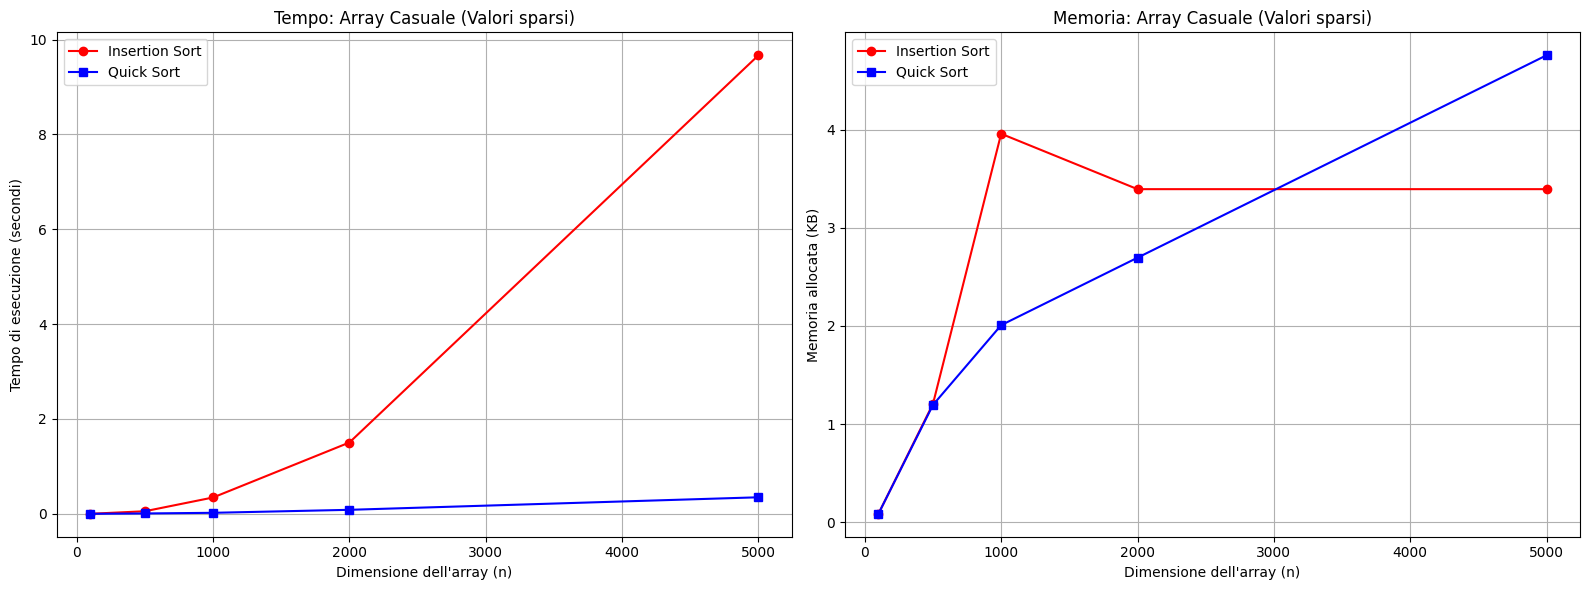

In [6]:
run_benchmark(generate_random_array, "Array Casuale (Valori sparsi)", ENABLE_MEMORY_BENCHMARK)

### Benchmark 2: Array Ordinato (crescente)
Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array ordinato in modo crescente, per confrontare le loro prestazioni nel caso migliore per _Insertion Sort_ e quello che rappresenterebbe il caso peggiore per il _Quick Sort_ classico (con pivot fisso), evidenziando così l'efficacia della variante randomizzata qui adottata.


--- BENCHMARK TEMPO + MEMORIA: Array Ordinato (Valori crescenti) ---
Dim	Tempo Ins	Mem Ins	Tempo QS	Mem QS
--------------------------------------------------------------------------------
100	0.000016	0.1KB	0.000222	0.1KB
500	0.000515	0.1KB	0.006283	2.6KB
1000	0.001575	0.1KB	0.016013	2.4KB
2000	0.003922	0.3KB	0.038914	2.4KB
5000	0.011684	0.9KB	0.115972	1.8KB


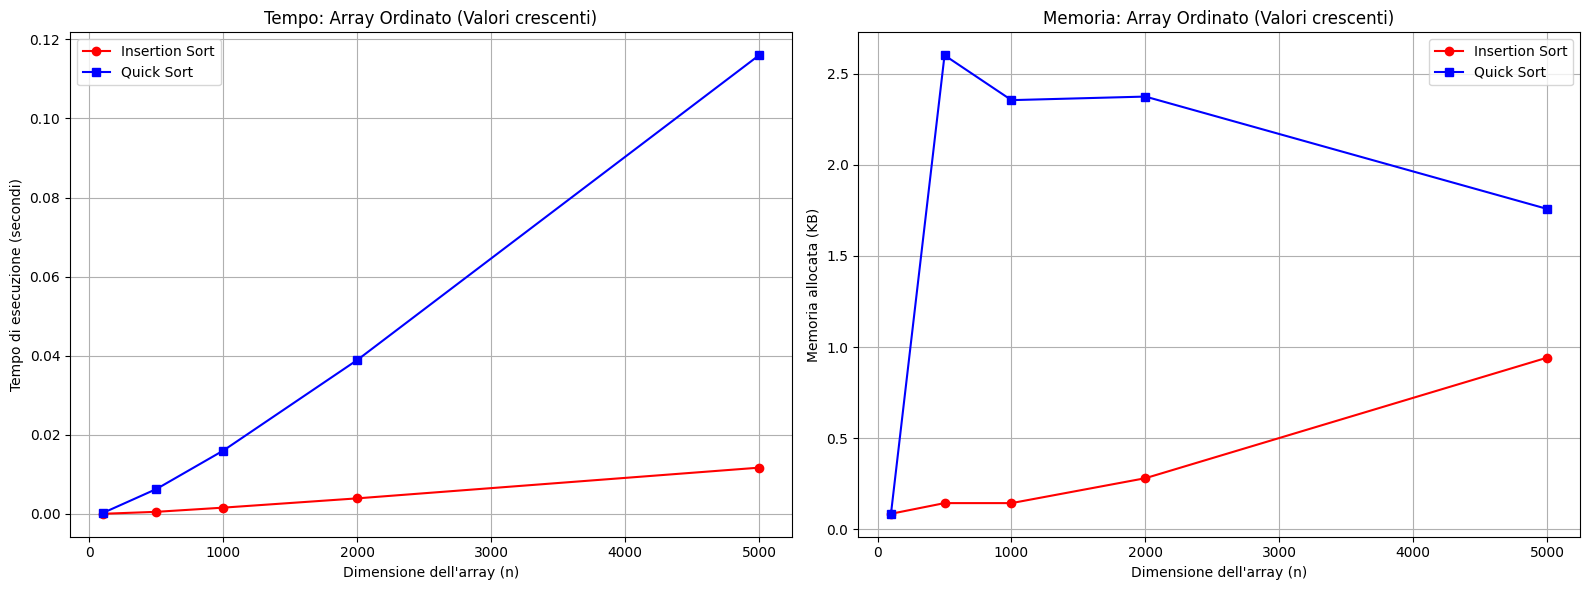

In [7]:
run_benchmark(generate_sorted_array, "Array Ordinato (Valori crescenti)", ENABLE_MEMORY_BENCHMARK)


### Benchmark 3: Array Ordinato (decrescente)
Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array ordinato in modo decrescente, per confrontare le loro prestazioni nel caso peggiore per _Insertion Sort_.

--- BENCHMARK TEMPO + MEMORIA: Array Ordinato (Valori decrescenti) ---
Dim	Tempo Ins	Mem Ins	Tempo QS	Mem QS
--------------------------------------------------------------------------------
100	0.000310	0.1KB	0.000247	0.1KB
500	0.055032	1.8KB	0.006021	2.0KB
1000	0.449393	3.5KB	0.016119	1.6KB
2000	2.560581	3.4KB	0.039065	1.4KB
5000	18.070557	3.3KB	0.118871	1.9KB


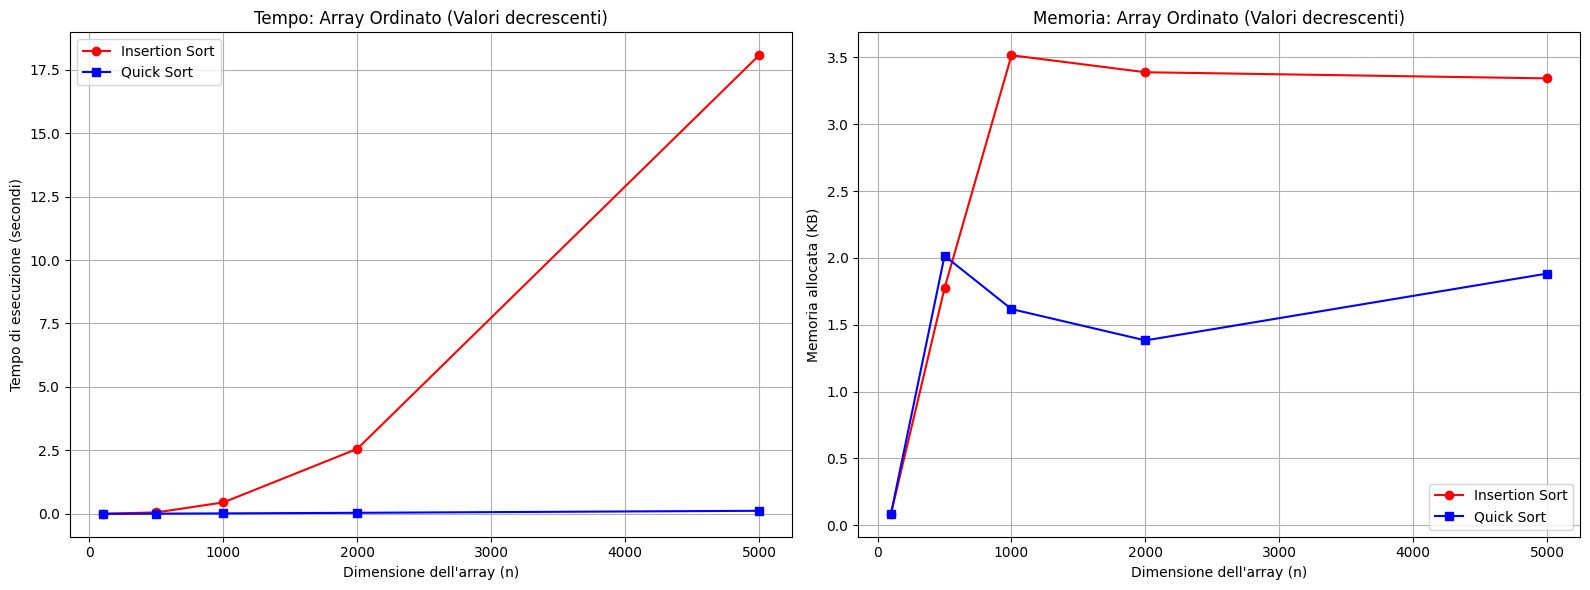

In [8]:
run_benchmark(generate_reverse_sorted_array, "Array Ordinato (Valori decrescenti)", ENABLE_MEMORY_BENCHMARK)

### Benchmark 4: Array Quasi Ordinato
Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array quasi ordinato, un contesto comune in molte applicazioni reali.

--- BENCHMARK TEMPO + MEMORIA: Array Quasi Ordinato ---
Dim	Tempo Ins	Mem Ins	Tempo QS	Mem QS
--------------------------------------------------------------------------------
100	0.000028	0.1KB	0.000257	0.1KB
500	0.005529	0.3KB	0.004740	1.1KB
1000	0.049849	1.5KB	0.016943	1.4KB
2000	0.160833	1.6KB	0.035519	1.5KB
5000	1.178677	3.5KB	0.110633	1.9KB


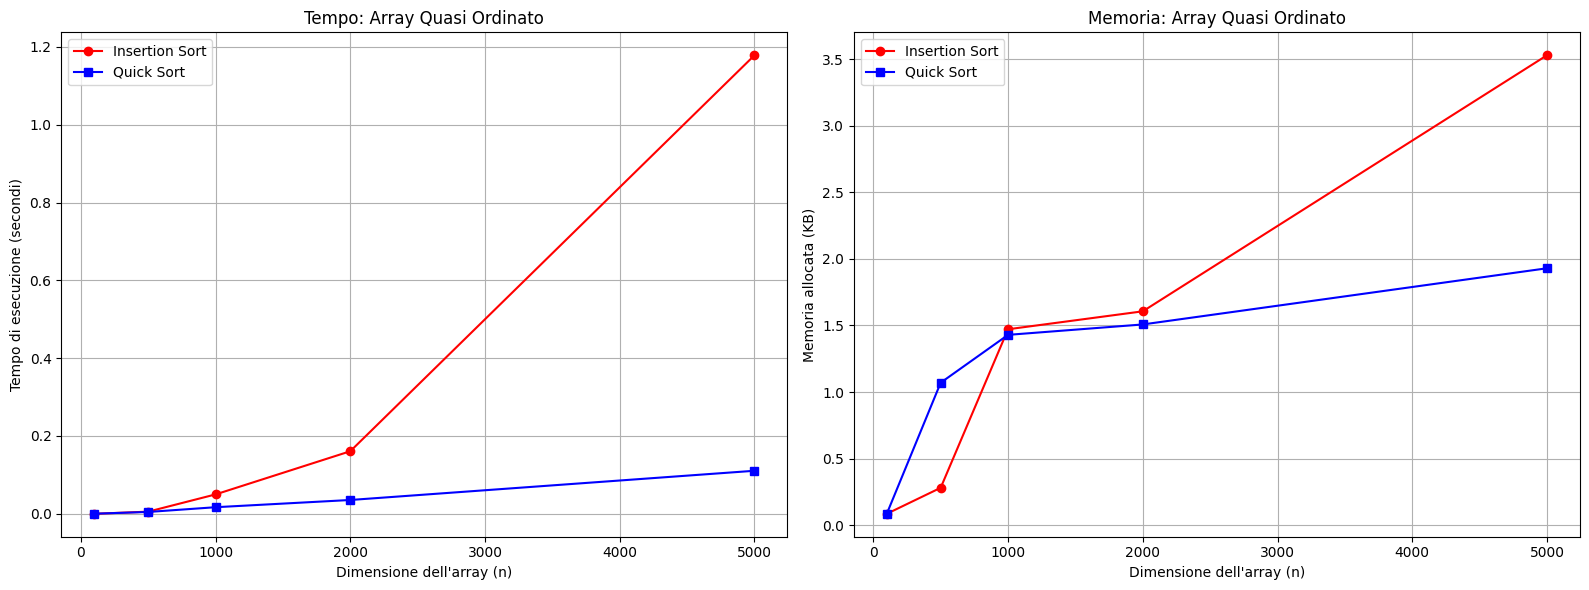

In [9]:
run_benchmark(generate_almost_sorted_array, "Array Quasi Ordinato", ENABLE_MEMORY_BENCHMARK)

### Benchmark 5: Array con Molti Duplicati
Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array con molti elementi duplicati, un contesto che si verifica spesso in dati reali.


--- BENCHMARK TEMPO + MEMORIA: Array Con molti duplicati ---
Dim	Tempo Ins	Mem Ins	Tempo QS	Mem QS
--------------------------------------------------------------------------------
100	0.000207	0.1KB	0.000709	0.1KB
500	0.044324	1.3KB	0.014020	3.9KB
1000	0.272803	4.0KB	0.080017	7.0KB
2000	1.318055	3.4KB	0.402951	13.0KB
5000	8.864704	3.4KB	4.187167	31.3KB


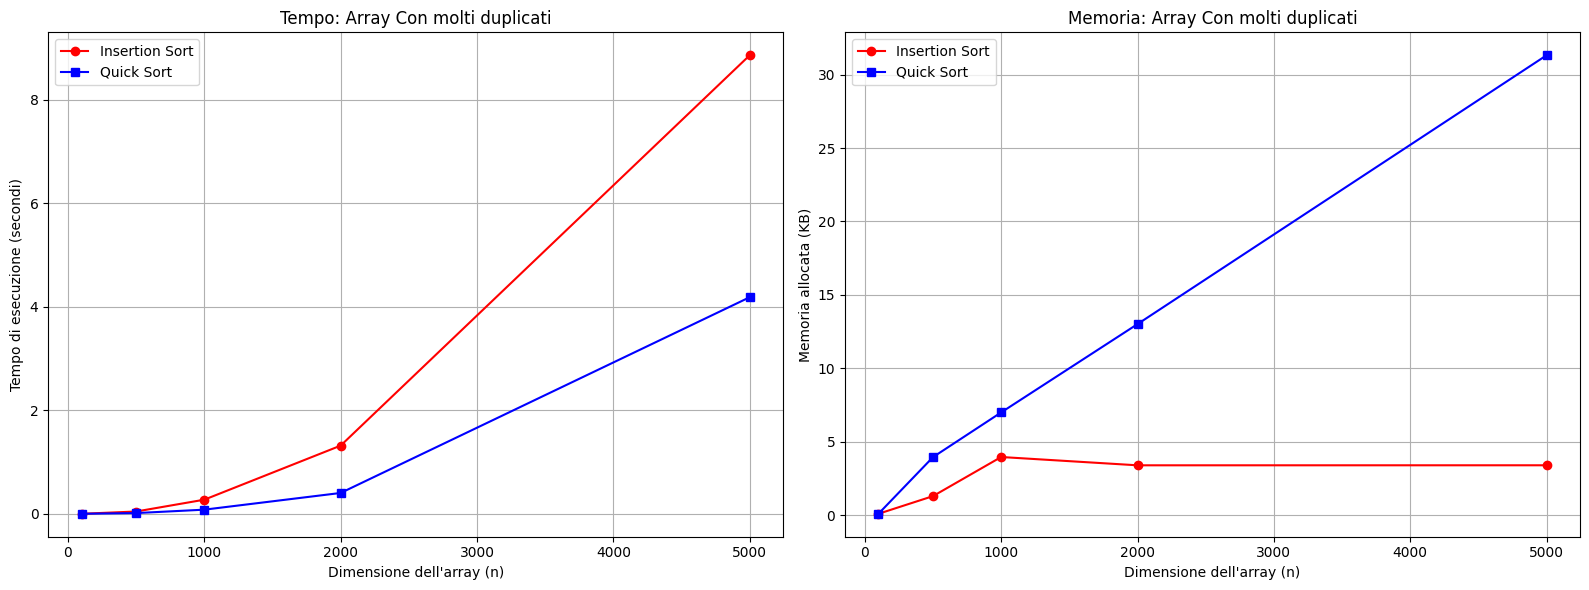

In [10]:
run_benchmark(generate_many_duplicates_array, "Array Con molti duplicati", ENABLE_MEMORY_BENCHMARK)

## Conclusioni Finali

L'analisi sperimentale condotta in questo notebook ha permesso di osservare come la teoria della complessità computazionale asintotica si traduca in prestazioni pratiche su input reali. Dal confronto tra **_Insertion Sort_** e **_Quick Sort_** (Randomizzato) sono emerse le seguenti evidenze:

* **Dominanza del Divide et Impera sui casi generici:**  
    Nei test con array casuali (Benchmark 1) e inversamente ordinati (Benchmark 3), il divario tra i due algoritmi è netto. Mentre l'_Insertion Sort_ manifesta la sua natura quadratica $O(n^2)$ degradando rapidamente all'aumentare di $n$, il _Quick Sort_ mantiene una crescita logaritmica $O(n \lg n)$, risultando ordini di grandezza più veloce. Il caso inversamente ordinato, in particolare, si conferma il peggiore in assoluto (worst-case) per l'_Insertion Sort_.  

* **L'efficacia del Pivot Randomico:**  
    Testando il _Quick Sort_ su un array già ordinato (Benchmark 2), non si è verificato il decadimento a $O(n^2)$ tipico della versione classica con pivot fisso. La variante *Randomized* implementata ha dimostrato la sua solidità. Estraendo il pivot in modo casuale, la probabilità di innescare il caso peggiore viene neutralizzata, garantendo prestazioni ottimali indipendentemente dalla disposizione iniziale dei dati.  

* **La nicchia di eccellenza dell'Insertion Sort:**  
    Nei contesti in cui l'array è già ordinato (Benchmark 2) o quasi del tutto ordinato (Benchmark 4), l'_Insertion Sort_ registra il suo tempo migliore (complessità lineare $O(n)$ o quasi-lineare). In questi specifici scenari, il ciclo interno non effettua scambi, rendendo questo semplice algoritmo iterativo estremamente competitivo, a tal punto da poter superare il _Quick Sort_ su dimensioni medio-piccole.  

* **Sensibilità ai dati duplicati (Benchmark 5):**  
    Il test sugli array con molti duplicati evidenzia un limite strutturale della partizione classica di Lomuto utilizzata nel _Quick Sort_, che tende a sbilanciarsi quando gestisce un'alta frequenza di valori identici, riducendo parzialmente il gap prestazionale con l'_Insertion Sort_.  

Nessun algoritmo è universalmente superiore, il **_Quick Sort_** Randomizzato si conferma l'algoritmo di riferimento (general-purpose) per dataset di grandi dimensioni grazie alla sua efficienza e sicurezza statistica. Tuttavia, l'**_Insertion Sort_** rimane uno strumento insostituibile per array di piccole dimensioni o quando si ha la garanzia che i dati in ingresso siano già parzialmente ordinati.